# Experimento 7 - SciBERT fine-tuned (solo la oracion de la cita)

Run: `scibert-sentence-finetuned-v1` | Modelo: `allenai/scibert_scivocab_uncased` + cabeza de clasificacion (fine-tuning completo).

**Idea.** Entrenar el encoder usando unicamente la oracion que contiene la cita, sin la oracion anterior ni la posterior, para medir el desempeno *sin contexto adicional*. Es la linea base contra la que se cuantifica el aporte del contexto: el experimento 6 (ventana de 3 oraciones) y las variantes de la actividad A4 (titulo/abstract, seccion + Top-3 chunks).

**De donde sale la oracion.** MultiCite publica el mismo conjunto en ventanas de 1 y 3 oraciones con identificadores identicos, asi que se une por `inst_id` con `classification_1_context` (fuente exacta) y, para las filas que no cruzan, se extrae localmente la oracion que contiene `<cite>`. Etiquetas y particiones son las del dataset balanceado del proyecto: el resultado es directamente comparable con el resto de runs del experimento `intencite-model-comparison`.

**Supuestos de ejecucion.** El notebook no instala paquetes, no clona repositorios y no sube archivos: se asume un entorno con las dependencias al dia (`transformers`, `datasets`, `mlflow`, `scikit-learn`, `matplotlib`), GPU disponible (T4 o L4) y el archivo `multicite_3ctx_balanceado.csv` en la misma carpeta del notebook. Lo unico que descarga es el release de 1 oracion de MultiCite, y solo cuando no lo encuentra en cache; la seccion 3 lo deja explicito en pantalla.

**Metricas registradas.** Por acuerdo del equipo, en MLflow se registran unicamente `accuracy`, `precision_macro`, `recall_macro`, `f1_macro` y `f1_micro`, con prefijo `val_` (y `test_` en la evaluacion final). Las curvas de loss y accuracy por epoca se siguen calculando y graficando en el notebook, y la figura se sube como artefacto, pero sus valores no entran a la lista de metricas del run. `LOG_TRAINING_CURVES=True` revierte esa decision si en algun momento quieren las curvas dentro de MLflow.

**Dependencias.** Ademas de las habituales hace falta `torchvision`, que no usa el modelo pero si el flavor `mlflow.transformers` al construir su pipeline. Debe corresponder a la version de `torch` instalada:

```
pip install torchvision
```

**Flags principales** (seccion 1): `SMOKE` (corrida rapida con pocos datos), `SENTENCE_SOURCE` (seccion 3), `TRACKED_METRICS` y `LOG_TRAINING_CURVES` (metricas), `SAVE_MODEL_LOCAL`, `LOG_MODEL_TO_MLFLOW` y `MODEL_FLAVOR` (seccion 13), `RUN_FINAL_TEST` (seccion 15).

## 1. Configuracion

Hiperparametros dimensionados para una GPU de 16 GB (T4 o L4): lotes de 32 en entrenamiento y 128 en evaluacion, precision mixta `fp16`, agrupacion por longitud para reducir el relleno y carga de datos en dos procesos. En CPU todo eso se desactiva solo y la corrida sigue funcionando, mucho mas lenta.

`MLFLOW_EXPERIMENT_KIND` fija la etiqueta `mlflow.experimentKind` del experimento. Es lo que hace que la interfaz de MLflow 3 lo muestre como *Machine learning*, con la pestana **Training runs**, en vez de la vista de GenAI con *Evaluation runs*.

Sobre el modelo entrenado: pesa unos 440 MB. Guardarlo en disco es inmediato; subirlo al servidor de tracking tarda lo que tarde la conexion, y esa es la celda que parece colgarse cuando se corre desde una maquina local. La seccion 13 imprime el tamano antes de empezar y el tiempo al terminar para que se vea el avance.

In [2]:
from pathlib import Path
import inspect
import json
import os
import re
import tempfile
import time
import urllib.request

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from mlflow.tracking import MlflowClient
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
import transformers
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainerCallback,
    TrainingArguments,
    set_seed,
)

SEED = 42
set_seed(SEED)

# -- Rutas: todo relativo a la carpeta del notebook ---------------------------
WORK_DIR = Path.cwd()
DATA_PATH = WORK_DIR / "multicite_3ctx_balanceado.csv"
MULTICITE_1CTX_DIR = WORK_DIR / "multicite_1ctx"      # cache de la descarga de MultiCite
MULTICITE_1CTX_URL = (
    "https://raw.githubusercontent.com/allenai/multicite/master/data/classification_1_context"
)

# -- Columnas y esquema de etiquetas ------------------------------------------
TEXT_COL = "context"          # ventana de 3 oraciones (entrada del experimento 6)
SENT_COL = "cite_sentence"    # solo la oracion que contiene la cita (entrada de este experimento)
ID_COL = "inst_id"            # id de instancia de MultiCite; une con el release de 1 oracion
LABEL_COL = "label_proyecto"
SPLIT_COL = "split_proyecto"
GROUP_COL = "pair_id"

LABELS = ["Application", "Background", "Comparison", "Gap", "Improvement"]
label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for label, i in label2id.items()}

# "auto": release oficial classification_1_context de MultiCite (unido por inst_id)
#         con heuristica local de respaldo.
# "release": solo el release (falla si no esta disponible).
# "heuristic": solo extraccion local a partir de `context`.
SENTENCE_SOURCE = "auto"

# -- Hardware ------------------------------------------------------------------
if torch.cuda.is_available():
    DEVICE = "cuda"
    GPU_NAME = torch.cuda.get_device_name(0)
    GPU_MEM_GB = torch.cuda.get_device_properties(0).total_memory / 1024 ** 3
else:
    DEVICE = "cpu"
    GPU_NAME, GPU_MEM_GB = "sin GPU", 0.0

USE_FP16 = DEVICE == "cuda"
DATALOADER_WORKERS = 2 if DEVICE == "cuda" else 0

# -- Modelo y entrenamiento ----------------------------------------------------
BASE_MODEL = "allenai/scibert_scivocab_uncased"
ADD_CITE_TOKENS = True            # <cite> y </cite> como tokens especiales del tokenizador

# Corrida rapida de toda la tuberia con pocos datos, para verificar el notebook.
SMOKE = False

if SMOKE:
    NUM_EPOCHS = 2
    MAX_TRAIN = 64
    MAX_EVAL = 32
    EARLY_STOPPING_PATIENCE = 1
    LOGGING_STEPS = 1
else:
    NUM_EPOCHS = 40               # tope; el early stopping decide cuando parar
    MAX_TRAIN = None              # None = dataset completo
    MAX_EVAL = None
    EARLY_STOPPING_PATIENCE = 3   # epocas sin mejora antes de detenerse
    LOGGING_STEPS = 10

MAX_LEN = 128                     # la oracion sola cabe de sobra (p95 ~ 60 palabras)
LEARNING_RATE = 2e-5
BATCH_SIZE = 32 if DEVICE == "cuda" else 8
EVAL_BATCH_SIZE = 128 if DEVICE == "cuda" else 32
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1                # 10% de los pasos totales como calentamiento
EARLY_STOPPING_THRESHOLD = 0.0    # mejora minima de la metrica para reiniciar la paciencia
METRIC_FOR_BEST = "f1_macro"

# -- MLflow --------------------------------------------------------------------
USE_MLFLOW = True
MLFLOW_EXPERIMENT = "intencite-model-comparison"
RUN_NAME = "scibert-sentence-finetuned-1-sentence" + ("-smoke" if SMOKE else "")
MODEL_NAME = f"best_model_{RUN_NAME}"

# Metricas acordadas por el equipo: son las unicas que se registran en MLflow.
TRACKED_METRICS = ["accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_micro"]
LOG_TRAINING_CURVES = False       # True vuelve a enviar loss/accuracy por paso al run

# El modelo pesa ~440 MB: guardarlo en disco es inmediato, subirlo tarda.
SAVE_MODEL_LOCAL = not SMOKE      # carpeta best_model_<run_name>/ junto al notebook
LOG_MODEL_TO_MLFLOW = not SMOKE   # subirlo al servidor de tracking
MODEL_FLAVOR = True               # via mlflow.transformers (LoggedModel); requiere torchvision

# Tipo de experimento en la UI de MLflow 3:
#   "custom_model_development" -> vista Machine learning, con pestana Training runs
#   "genai_development"        -> vista GenAI, con Evaluation runs
MLFLOW_EXPERIMENT_KIND = "custom_model_development"

# Servidor de tracking; MLFLOW_TRACKING_URI en el entorno lo sobreescribe.
MLFLOW_REMOTE_URI = "http://98.80.92.131:8080"
MLFLOW_TRACKING_URI = os.environ.get("MLFLOW_TRACKING_URI", MLFLOW_REMOTE_URI).rstrip("/")


def ensure_experiment(name, kind=None):
    """Selecciona el experimento y fija su tipo para que la UI muestre Training runs.

    Devuelve el objeto Experiment; su experiment_id se le pasa despues a
    mlflow.start_run() en lugar de depender del experimento activo global.
    """
    kind = kind or MLFLOW_EXPERIMENT_KIND
    experiment = mlflow.set_experiment(name)
    try:
        MlflowClient().set_experiment_tag(experiment.experiment_id, "mlflow.experimentKind", kind)
    except Exception as exc:
        print(f"AVISO: no se pudo etiquetar {name} como {kind}: {exc}")
    return mlflow.get_experiment(experiment.experiment_id)


print("Carpeta de trabajo :", WORK_DIR)
print("Dataset            :", DATA_PATH)
print(f"Dispositivo        : {DEVICE} ({GPU_NAME}, {GPU_MEM_GB:.1f} GB)" if DEVICE == "cuda"
      else f"Dispositivo        : {DEVICE}")
print(f"Lotes              : train {BATCH_SIZE} | eval {EVAL_BATCH_SIZE} | fp16 {USE_FP16}")
print("Modelo base        :", BASE_MODEL)
print("MLflow             :", MLFLOW_TRACKING_URI)
print("Experimento        :", MLFLOW_EXPERIMENT, f"({MLFLOW_EXPERIMENT_KIND})")
print("Run                :", RUN_NAME)
print("Metricas           :", ", ".join(TRACKED_METRICS))
print("Modelo             :", f"local={SAVE_MODEL_LOCAL} | MLflow={LOG_MODEL_TO_MLFLOW} | flavor={MODEL_FLAVOR}")
print("SMOKE              :", SMOKE)

Carpeta de trabajo : /content
Dataset            : /content/multicite_3ctx_balanceado.csv
Dispositivo        : cuda (Tesla T4, 14.6 GB)
Lotes              : train 32 | eval 128 | fp16 True
Modelo base        : allenai/scibert_scivocab_uncased
MLflow             : http://98.80.92.131:8080
Experimento        : intencite-model-comparison (custom_model_development)
Run                : scibert-sentence-finetuned-1-sentence
Metricas           : accuracy, precision_macro, recall_macro, f1_macro, f1_micro
Modelo             : local=True | MLflow=True | flavor=True
SMOKE              : False


## 2. Carga y validacion del dataset

`multicite_3ctx_balanceado.csv` debe estar junto al notebook.

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No encontre {DATA_PATH.name} en {WORK_DIR}. "
        "Copia multicite_3ctx_balanceado.csv a la misma carpeta del notebook."
    )

df = pd.read_csv(DATA_PATH)

required = {TEXT_COL, LABEL_COL, SPLIT_COL, GROUP_COL}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Faltan columnas obligatorias: {missing}")

model_df = df.dropna(subset=[TEXT_COL, LABEL_COL, SPLIT_COL, GROUP_COL]).copy()
model_df[TEXT_COL] = model_df[TEXT_COL].astype(str)
model_df[LABEL_COL] = model_df[LABEL_COL].astype(str)

unknown = set(model_df[LABEL_COL]) - set(LABELS)
if unknown:
    raise ValueError(f"Etiquetas fuera del esquema de cinco clases: {unknown}")

sin_marcador = int((~model_df[TEXT_COL].str.contains("<cite>", regex=False)).sum())

print("Shape:", model_df.shape)
print("Columnas:", list(model_df.columns))
print("Contextos sin marcador <cite>:", sin_marcador)
print("\nSplits:")
print(model_df[SPLIT_COL].value_counts())
print("\nClases:")
print(model_df[LABEL_COL].value_counts())

Shape: (3491, 9)
Columnas: ['split_proyecto', 'label_proyecto', 'inst_id', 'pair_id', 'context', 'y_raw', 'labels', 'n_words', 'sec_canon']
Contextos sin marcador <cite>: 0

Splits:
split_proyecto
train    2491
test      517
val       483
Name: count, dtype: int64

Clases:
label_proyecto
Gap            700
Comparison     700
Application    700
Background     700
Improvement    691
Name: count, dtype: int64


## 3. La oracion de la cita (entrada sin contexto adicional)

`context` es la ventana de 3 oraciones de MultiCite (`classification_3_context`). El mismo repositorio publica `classification_1_context`, donde `x` es solo la oracion citante, con los mismos `id`. Por eso la oracion se obtiene en dos vias:

1. **Release oficial** (`SENTENCE_SOURCE="auto"|"release"`): fuente exacta, unida por `inst_id`. **Este es el unico paso del notebook que descarga algo de internet.** Los tres archivos (`train`, `dev`, `test`) se guardan en `multicite_1ctx/` junto al notebook; la celda imprime si los tomo del cache o si tuvo que bajarlos, con la URL y el tamano de cada uno. Si ya estan en disco no hay trafico de red.
2. **Heuristica local** (respaldo, o `SENTENCE_SOURCE="heuristic"`): se segmenta `context` en oraciones protegiendo el span `<cite>...</cite>`, abreviaturas (`et al.`, `e.g.`, `Fig.`) y decimales, y se conservan las oraciones que contienen `<cite>`. Si ninguna lo contiene, se usa el contexto completo para no perder la fila.

Se registra la procedencia de cada oracion (`sentence_source`) y se reporta cuanto se reduce la entrada respecto al contexto: esa reduccion es exactamente lo que este experimento mide.

In [4]:
_ABBREVIATIONS = [
    "et al.", "e.g.", "i.e.", "cf.", "vs.", "viz.", "resp.", "approx.",
    "Fig.", "Figs.", "Eq.", "Eqs.", "Sec.", "Secs.", "Tab.", "Ref.", "Refs.",
    "No.", "Vol.", "pp.", "Ch.", "Dr.", "Prof.", "Mr.", "Ms.", "Mrs.", "St.",
]
_SECTION_HEADER = re.compile(r"\*\*[^*]{1,60}\*\*\s*")   # encabezados **INTRODUCTION**
_CITE_SPAN = re.compile(r"<cite>.*?</cite>", flags=re.DOTALL)
_BOUNDARY = re.compile(r"(?<=[.!?])\s+(?=[^a-z\s])")
_DOT, _TAG = "\x01", "\x02"


def split_sentences(text: str) -> list:
    """Segmenta un contexto de MultiCite en oraciones sin romper los spans <cite>."""
    text = re.sub(r"\s+", " ", text).strip()
    text = _SECTION_HEADER.sub("", text)

    spans = []

    def _protect(match):
        spans.append(match.group(0))
        return f"{_TAG}{len(spans) - 1}{_TAG}"

    protected = _CITE_SPAN.sub(_protect, text)
    for abbr in _ABBREVIATIONS:
        protected = protected.replace(abbr, abbr.replace(".", _DOT))
    protected = re.sub(r"(?<=\d)\.(?=\d)", _DOT, protected)                    # 3.5
    protected = re.sub(r"\b([A-Z])\.(?=\s[A-Z])", rf"\1{_DOT}", protected)     # J. Smith

    def _restore(chunk):
        chunk = chunk.replace(_DOT, ".")
        return re.sub(rf"{_TAG}(\d+){_TAG}", lambda m: spans[int(m.group(1))], chunk)

    return [_restore(s).strip() for s in _BOUNDARY.split(protected) if s.strip()]


def extract_cite_sentence(context: str) -> tuple:
    """Devuelve (oracion, fuente). fuente: 'heuristic' o 'context' (respaldo)."""
    if not isinstance(context, str) or not context.strip():
        return "", "context"
    hits = [s for s in split_sentences(context) if "<cite>" in s]
    if not hits:
        return re.sub(r"\s+", " ", _SECTION_HEADER.sub("", context)).strip(), "context"
    return " ".join(hits), "heuristic"


def load_multicite_1ctx(cache_dir: Path) -> dict:
    """Devuelve {inst_id: oracion} de classification_1_context, descargando si hace falta."""
    cache_dir.mkdir(parents=True, exist_ok=True)
    mapping = {}
    descargados = []

    print(f"Release 1-context de MultiCite | cache: {cache_dir}")
    for split in ("train", "dev", "test"):
        dest = cache_dir / f"{split}.json"
        if dest.exists() and dest.stat().st_size > 0:
            print(f"  [cache]     {dest.name:10s} {dest.stat().st_size / 1024:8.0f} KB")
        else:
            url = f"{MULTICITE_1CTX_URL}/{split}.json"
            print(f"  [DESCARGA]  {dest.name:10s} <- {url}")
            urllib.request.urlretrieve(url, dest)
            descargados.append(split)
            print(f"              {'':10s} {dest.stat().st_size / 1024:8.0f} KB guardados")

        for rec in json.loads(dest.read_text(encoding="utf-8")):
            x = rec["x"]
            if isinstance(x, list):       # rareza del release: algunos x vienen en lista
                x = x[0] if x else ""
            mapping[rec["id"]] = re.sub(r"\s+", " ", x or "").strip()

    if descargados:
        print(f"  --> se descargaron de internet: {', '.join(descargados)}")
        print(f"      quedan en {cache_dir}; la proxima corrida no vuelve a bajarlos")
    else:
        print("  --> nada que descargar, todo estaba en cache")
    print(f"  {len(mapping):,} oraciones disponibles\n")
    return mapping


ejemplo = ("**RESULTS** We first train a baseline on the full corpus. Following the setup of "
           "<cite>Smith et al. (2020)</cite> , we use 3.5 % of the data for validation. "
           "Table 2 reports the results.")
print(extract_cite_sentence(ejemplo))

('Following the setup of <cite>Smith et al. (2020)</cite> , we use 3.5 % of the data for validation.', 'heuristic')


In [5]:
sentence_map = {}
if SENTENCE_SOURCE in ("auto", "release"):
    if ID_COL not in model_df.columns:
        msg = f"el dataset no tiene la columna {ID_COL!r}; no se puede unir con el release 1-context."
        if SENTENCE_SOURCE == "release":
            raise ValueError(msg)
        print("AVISO:", msg, "Se usara la heuristica.\n")
    else:
        try:
            sentence_map = load_multicite_1ctx(MULTICITE_1CTX_DIR)
        except Exception as exc:
            if SENTENCE_SOURCE == "release":
                raise
            print("AVISO: no se pudo obtener el release 1-context; se usara la heuristica:", exc, "\n")


def resolve_sentence(row):
    if sentence_map:
        candidate = sentence_map.get(row[ID_COL], "")
        if "<cite>" in candidate:
            return candidate, "release"
    return extract_cite_sentence(row[TEXT_COL])


resolved = model_df.apply(resolve_sentence, axis=1, result_type="expand")
model_df[SENT_COL] = resolved[0].astype(str)
model_df["sentence_source"] = resolved[1]

assert model_df[SENT_COL].str.strip().str.len().gt(0).all(), "hay oraciones vacias"

_norm = lambda t: re.sub(r"[^a-z0-9<>/]+", " ", t.lower()).strip()
contained = float(np.mean([
    _norm(s) in _norm(c) for s, c in zip(model_df[SENT_COL], model_df[TEXT_COL])
]))
words_ctx = model_df[TEXT_COL].str.split().str.len()
words_sent = model_df[SENT_COL].str.split().str.len()

sentence_stats = {
    "n_from_release": int((model_df["sentence_source"] == "release").sum()),
    "n_from_heuristic": int((model_df["sentence_source"] == "heuristic").sum()),
    "n_fallback_context": int((model_df["sentence_source"] == "context").sum()),
    "sentence_in_context_ratio": round(contained, 4),
    "words_context_median": float(words_ctx.median()),
    "words_sentence_median": float(words_sent.median()),
    "words_context_p95": float(words_ctx.quantile(0.95)),
    "words_sentence_p95": float(words_sent.quantile(0.95)),
}

total = len(model_df)
print("Procedencia de la oracion de cita:")
print(f"  release descargado : {sentence_stats['n_from_release']:6,} ({sentence_stats['n_from_release'] / total:.1%})")
print(f"  heuristica local   : {sentence_stats['n_from_heuristic']:6,} ({sentence_stats['n_from_heuristic'] / total:.1%})")
print(f"  contexto completo  : {sentence_stats['n_fallback_context']:6,} ({sentence_stats['n_fallback_context'] / total:.1%})")
print(f"\nLa oracion conserva en mediana el {words_sent.median() / words_ctx.median():.0%} "
      f"de las palabras del contexto ({words_ctx.median():.0f} -> {words_sent.median():.0f}).")

pd.set_option("display.max_colwidth", 170)
model_df.sample(3, random_state=SEED)[[LABEL_COL, "sentence_source", TEXT_COL, SENT_COL]]

Release 1-context de MultiCite | cache: /content/multicite_1ctx
  [cache]     train.json     1629 KB
  [cache]     dev.json        753 KB
  [cache]     test.json       967 KB
  --> nada que descargar, todo estaba en cache
  11,251 oraciones disponibles

Procedencia de la oracion de cita:
  release descargado :  3,487 (99.9%)
  heuristica local   :      4 (0.1%)
  contexto completo  :      0 (0.0%)

La oracion conserva en mediana el 39% de las palabras del contexto (72 -> 28).


,label_proyecto,sentence_source,context,cite_sentence
295,Comparison,release,"Should we mark the definiendum before encoding, then only the definiendum embedding is passed into the encoder: the resulting system provides out-of-context definitio...","Should we mark the definiendum before encoding, then only the definiendum embedding is passed into the encoder: the resulting system provides out-of-context definitio..."
718,Application,release,"Following [<cite>13</cite>] , we use an LST M to encode the history h t = {e t−k , r t−k+1 , ..., e t−1 , r t } of the past k steps taken by the agent in solving the ...","Following [<cite>13</cite>] , we use an LST M to encode the history h t = {e t−k , r t−k+1 , ..., e t−1 , r t } of the past k steps taken by the agent in solving the ..."
952,Comparison,release,"Prior work (Vlachos and Riedel, 2014; Ciampaglia et al., 2015) have proposed fact-checking through entailment from knowledge bases. Some works have investigated fact ...","Most closely related to our work, <cite>Thorne et al. (2018)</cite> addresses large-scale fact extraction and verification task using a pipeline approach."


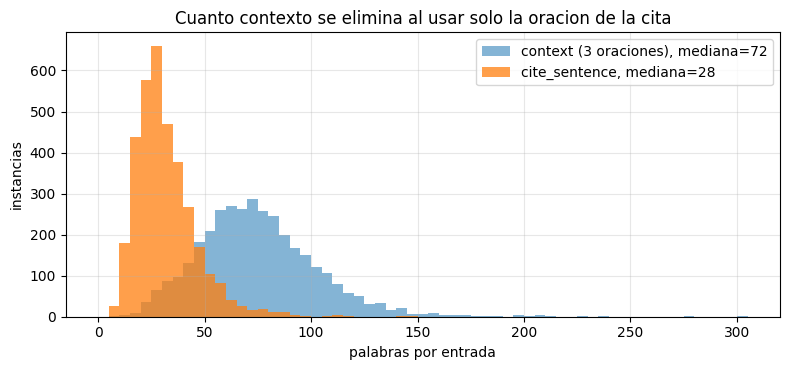

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.8))
bins = np.arange(0, max(words_ctx.max(), words_sent.max()) + 5, 5)
ax.hist(words_ctx, bins=bins, alpha=0.55, label=f"context (3 oraciones), mediana={words_ctx.median():.0f}")
ax.hist(words_sent, bins=bins, alpha=0.75, label=f"cite_sentence, mediana={words_sent.median():.0f}")
ax.set_xlabel("palabras por entrada")
ax.set_ylabel("instancias")
ax.set_title("Cuanto contexto se elimina al usar solo la oracion de la cita")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Particiones oficiales y control de leakage

In [7]:
train_df = model_df[model_df[SPLIT_COL] == "train"].copy()
val_df = model_df[model_df[SPLIT_COL] == "val"].copy()
test_df = model_df[model_df[SPLIT_COL] == "test"].copy()

train_pairs = set(train_df[GROUP_COL])
val_pairs = set(val_df[GROUP_COL])
test_pairs = set(test_df[GROUP_COL])

assert train_pairs.isdisjoint(val_pairs)
assert train_pairs.isdisjoint(test_pairs)
assert val_pairs.isdisjoint(test_pairs)


def balanced_head(frame, total):
    per_class = total // len(LABELS)
    parts = [
        g.sample(min(len(g), per_class), random_state=SEED)
        for _, g in frame.groupby(LABEL_COL)
    ]
    return pd.concat(parts).sample(frac=1, random_state=SEED)


if MAX_TRAIN is not None:
    train_df = balanced_head(train_df, MAX_TRAIN)
if MAX_EVAL is not None:
    val_df = balanced_head(val_df, MAX_EVAL)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))
print("OK: cero solapamiento de pair_id entre train, val y test.")

Train: 2491
Val: 483
Test: 517
OK: cero solapamiento de pair_id entre train, val y test.


## 5. Tokenizador y modelo

SciBERT con una cabeza lineal de 5 salidas (`AutoModelForSequenceClassification`). Los marcadores `<cite>` y `</cite>` se agregan como tokens especiales para que el modelo sepa donde esta la referencia objetivo en vez de verlos como `<`, `cite`, `>`.

Esta celda imprime un **LOAD REPORT** que no es un error y que conviene leer una vez:

- `cls.predictions.*` y `cls.seq_relationship.*` como `UNEXPECTED`: son las cabezas de preentrenamiento (prediccion de palabra enmascarada y de siguiente oracion) de SciBERT. Este experimento no las usa y se descartan.
- `classifier.weight` y `classifier.bias` como `MISSING`: es la cabeza de clasificacion de 5 clases, que no existe en el checkpoint y se inicializa al azar. Entrenarla es justamente el objetivo del fine-tuning.
- El aviso de `mean_resizing` corresponde a `resize_token_embeddings`: los vectores de `<cite>` y `</cite>` se inicializan con la media y covarianza de los embeddings existentes, que es el comportamiento deseado.

SciBERT es un modelo publico, asi que **no hace falta token de Hugging Face**. La prueba de que la descarga funciono esta en las dos ultimas lineas: el conteo de parametros y la tokenizacion, donde `<cite>` aparece como un unico token.

In [8]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
if ADD_CITE_TOKENS:
    added = tokenizer.add_special_tokens({"additional_special_tokens": ["<cite>", "</cite>"]})
    print("Tokens especiales agregados:", added)

model = AutoModelForSequenceClassification.from_pretrained(
    BASE_MODEL,
    num_labels=len(LABELS),
    id2label=id2label,
    label2id=label2id,
)
if ADD_CITE_TOKENS:
    model.resize_token_embeddings(len(tokenizer))

n_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"{model.config.model_type} - {n_params:.1f} M parametros (todos entrenables)")
print(tokenizer.tokenize("We follow <cite>Smith et al. (2020)</cite> to train the model."))

Tokens especiales agregados: 2


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: allenai/scibert_scivocab_uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those

bert - 109.9 M parametros (todos entrenables)
['we', 'follow', '<cite>', 'smith', 'et', 'al', '.', '(', '202', '##0', ')', '</cite>', 'to', 'train', 'the', 'model', '.']


In [9]:
def token_lengths(texts):
    enc = tokenizer(list(texts), truncation=False, add_special_tokens=True)
    return pd.Series([len(ids) for ids in enc["input_ids"]])


len_sent = token_lengths(model_df[SENT_COL])
len_ctx = token_lengths(model_df[TEXT_COL])
n_truncated = int((len_sent > MAX_LEN).sum())

print(f"Tokens oracion : mediana {len_sent.median():.0f} | p95 {len_sent.quantile(0.95):.0f} | max {len_sent.max()}")
print(f"Tokens contexto: mediana {len_ctx.median():.0f} | p95 {len_ctx.quantile(0.95):.0f} | max {len_ctx.max()}")
print(f"Oraciones truncadas con MAX_LEN={MAX_LEN}: {n_truncated} ({n_truncated / len(len_sent):.2%})")

Tokens oracion : mediana 44 | p95 87 | max 257
Tokens contexto: mediana 103 | p95 176 | max 424
Oraciones truncadas con MAX_LEN=128: 24 (0.69%)


## 6. Datasets tokenizados

Truncado a `MAX_LEN` y relleno dinamico por lote (`DataCollatorWithPadding`): cada lote se rellena a la longitud de su elemento mas largo, no a 128 fijo.

In [10]:
def build_dataset(frame):
    ds = Dataset.from_dict({
        "text": frame[SENT_COL].tolist(),
        "labels": [label2id[label] for label in frame[LABEL_COL]],
    })
    return ds.map(
        lambda batch: tokenizer(batch["text"], truncation=True, max_length=MAX_LEN),
        batched=True,
        remove_columns=["text"],
    )


train_ds = build_dataset(train_df)
val_ds = build_dataset(val_df)

print(train_ds)
print(tokenizer.decode(train_ds[0]["input_ids"]))
print("label:", id2label[train_ds[0]["labels"]])

Map:   0%|          | 0/2491 [00:00<?, ? examples/s]

Map:   0%|          | 0/483 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2491
})
[CLS] most previous systems built to identify fake news articles rely on training data labeled with respect to the general reputation of the sources, i. e., domains / user accounts ( fogg et al., 2001 ; lazer et al., 2017 ; <cite> rashkin et al., 2017 ) </cite>. [SEP]
label: Gap


## 7. Metricas y callbacks

`compute_metrics` se evalua al final de cada epoca sobre validacion: de ahi salen las metricas que usan el early stopping y las curvas del notebook.

`MLflowMetricsCallback` enviaria ademas cada linea de log del `Trainer` al run (loss por paso, metricas de validacion por epoca). Queda **desactivado** por el acuerdo de metricas del equipo, y solo se engancha si `LOG_TRAINING_CURVES=True`. Las curvas siguen viendose en la seccion 10 y la figura se sube como artefacto.

In [11]:
def score(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "f1_micro": f1_score(y_true, y_pred, average="micro"),
    }


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
    return score(labels, np.argmax(logits, axis=-1))


class MLflowMetricsCallback(TrainerCallback):
    """Registra en el run activo de MLflow las curvas de loss/accuracy/F1 paso a paso."""

    RENAME = {
        "loss": "train_loss",
        "grad_norm": "train_grad_norm",
        "train_loss": "train_loss_avg",   # promedio final que reporta el Trainer
    }
    SKIP = {
        "eval_runtime", "eval_samples_per_second", "eval_steps_per_second",
        "train_runtime", "train_samples_per_second", "train_steps_per_second", "total_flos",
    }

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs or not state.is_world_process_zero:
            return
        if not USE_MLFLOW or mlflow.active_run() is None:
            return
        metrics = {
            self.RENAME.get(key, key): float(value)
            for key, value in logs.items()
            if key not in self.SKIP and isinstance(value, (int, float))
        }
        if metrics:
            mlflow.log_metrics(metrics, step=state.global_step)

## 8. Inicio del run en MLflow

El run se abre **antes** de entrenar y se cierra en la seccion 13: mientras el entrenamiento avanza, la corrida ya aparece en *Training runs* con estado `RUNNING` y sus metricas se actualizan en vivo.

`ensure_experiment()` devuelve el experimento y su `experiment_id` se le pasa explicitamente a `mlflow.start_run()`. Re-ejecutar esta celda cierra el run anterior en lugar de anidar uno nuevo.

In [12]:
def mlf_active():
    return USE_MLFLOW and mlflow.active_run() is not None


def mlf_log_scores(metrics, prefix):
    """Registra solo las metricas acordadas por el equipo, con el prefijo dado."""
    selected = {f"{prefix}_{k}": float(v) for k, v in metrics.items() if k in TRACKED_METRICS}
    ignoradas = sorted(set(metrics) - set(TRACKED_METRICS))
    if mlf_active():
        mlflow.log_metrics(selected)
    if ignoradas:
        print("(fuera del acuerdo, no se registran:", ", ".join(ignoradas) + ")")
    return selected


def mlf_log_artifact(path, artifact_path=None):
    if mlf_active():
        mlflow.log_artifact(str(path), artifact_path=artifact_path)


RUN_ID = None
EXPERIMENT_ID = None

if USE_MLFLOW:
    mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
    if mlflow.active_run() is not None:
        mlflow.end_run()

    experiment = ensure_experiment(MLFLOW_EXPERIMENT)
    run = mlflow.start_run(experiment_id=experiment.experiment_id, run_name=RUN_NAME)
    RUN_ID = run.info.run_id
    EXPERIMENT_ID = run.info.experiment_id

    mlflow.log_params({
        "base_model": BASE_MODEL,
        "method": "full-fine-tuning",
        "context": "sentence",
        "input_unit": SENT_COL,
        "sentence_source": SENTENCE_SOURCE,
        "add_cite_tokens": ADD_CITE_TOKENS,
        "max_len": MAX_LEN,
        "n_truncated": n_truncated,
        "learning_rate": LEARNING_RATE,
        "num_epochs_max": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "eval_batch_size": EVAL_BATCH_SIZE,
        "weight_decay": WEIGHT_DECAY,
        "warmup_ratio": WARMUP_RATIO,
        "lr_scheduler": "linear",
        "fp16": USE_FP16,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "early_stopping_threshold": EARLY_STOPPING_THRESHOLD,
        "metric_for_best": METRIC_FOR_BEST,
        "seed": SEED,
        "smoke": SMOKE,
        "device": DEVICE,
        "gpu": GPU_NAME,
        "train_rows": len(train_df),
        "val_rows": len(val_df),
        "test_rows": len(test_df),
        **{f"data_{k}": v for k, v in sentence_stats.items()},
    })

    mlflow.set_tags({
        "project": "IntenCite",
        "stage": "experiment",
        "model_family": "encoder_finetuned",
        "dataset": "multicite_3ctx_proyecto",
        "input": "cite_sentence",
        "baseline_for": "context-ablation",
    })

    print("MLflow run ID :", RUN_ID)
    print("Experimento   :", MLFLOW_EXPERIMENT, f"(id {EXPERIMENT_ID})")
    print("experimentKind:", experiment.tags.get("mlflow.experimentKind", "(sin etiqueta)"))
    print("Run           :", RUN_NAME)
    artifact_location = mlflow.get_experiment(EXPERIMENT_ID).artifact_location
    print("Artefactos    :", artifact_location)
    if MLFLOW_TRACKING_URI.startswith("http"):
        print("URL           :", f"{MLFLOW_TRACKING_URI}/#/experiments/{EXPERIMENT_ID}/runs/{RUN_ID}")
        if not artifact_location.startswith("mlflow-artifacts:"):
            print("AVISO: el experimento no usa el proxy de artefactos; la subida desde un")
            print("       cliente remoto puede fallar (revisa --serve-artifacts en el servidor).")
else:
    print("USE_MLFLOW=False: no se abrio ningun run.")

MLflow run ID : 1830ccb55b424fdc8a2a4f7ed8e633f5
Experimento   : intencite-model-comparison (id 2)
experimentKind: custom_model_development
Run           : scibert-sentence-finetuned-1-sentence
Artefactos    : mlflow-artifacts:/2
URL           : http://98.80.92.131:8080/#/experiments/2/runs/1830ccb55b424fdc8a2a4f7ed8e633f5


## 9. Entrenamiento con early stopping

Se evalua al final de cada epoca. `EarlyStoppingCallback` detiene el entrenamiento cuando el F1 macro de validacion no mejora en `EARLY_STOPPING_PATIENCE` epocas consecutivas (con `NUM_EPOCHS` como tope) y `load_best_model_at_end=True` restaura los pesos de la mejor epoca, no los de la ultima. Si algo falla, el run queda marcado `FAILED` en MLflow.

Ajustes para GPU: `fp16` en tarjetas T4/L4, `group_by_length` para que cada lote junte oraciones de longitud parecida y se pierda menos computo en relleno, y dos procesos de carga de datos con memoria fijada. `warmup_ratio` desaparecio en `transformers` v5 y se fusiono en `warmup_steps`, que ahora interpreta un float menor que 1 como proporcion; el bloque de abajo detecta cual de los dos acepta la version instalada.

In [13]:
_TA_PARAMS = set(inspect.signature(TrainingArguments.__init__).parameters)
warmup_kwargs = ({"warmup_ratio": WARMUP_RATIO} if "warmup_ratio" in _TA_PARAMS
                 else {"warmup_steps": WARMUP_RATIO})
print("Warmup:", warmup_kwargs)

if DEVICE == "cuda":
    torch.cuda.empty_cache()

training_args = TrainingArguments(
    output_dir=tempfile.mkdtemp(prefix="scibert_sentence_"),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    **warmup_kwargs,
    lr_scheduler_type="linear",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model=METRIC_FOR_BEST,
    greater_is_better=True,
    logging_strategy="steps",
    logging_steps=LOGGING_STEPS,
    fp16=USE_FP16,
    dataloader_num_workers=DATALOADER_WORKERS,
    dataloader_pin_memory=(DEVICE == "cuda"),
    report_to="none",
    seed=SEED,
)

callbacks = [
    EarlyStoppingCallback(
        early_stopping_patience=EARLY_STOPPING_PATIENCE,
        early_stopping_threshold=EARLY_STOPPING_THRESHOLD,
    ),
]
if LOG_TRAINING_CURVES:
    callbacks.append(MLflowMetricsCallback())

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=callbacks,
)

try:
    train_result = trainer.train()
except BaseException:
    if mlf_active():
        mlflow.end_run(status="FAILED")
    raise

epochs_trained = float(trainer.state.epoch or 0.0)
early_stopped = epochs_trained < NUM_EPOCHS - 1e-6
best_metric = float(trainer.state.best_metric) if trainer.state.best_metric is not None else float("nan")

print(train_result.metrics)
print(f"\nEpocas entrenadas: {epochs_trained:.0f} de {NUM_EPOCHS} | early stopping: {'si' if early_stopped else 'no'}")
print(f"Mejor eval_{METRIC_FOR_BEST}: {best_metric:.4f} | checkpoint restaurado: {trainer.state.best_model_checkpoint}")
if DEVICE == "cuda":
    print(f"Memoria GPU maxima usada: {torch.cuda.max_memory_allocated() / 1024 ** 3:.2f} GB de {GPU_MEM_GB:.1f} GB")

Warmup: {'warmup_steps': 0.1}


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Micro
1,1.496260,1.400855,0.465839,0.496956,0.473026,0.451399,0.465839
2,1.164740,1.117113,0.590062,0.595409,0.592152,0.584516,0.590062
3,1.020592,0.994505,0.625259,0.635494,0.626654,0.622304,0.625259
4,0.966163,0.971355,0.660455,0.669262,0.655268,0.649215,0.660455
5,0.697041,1.027610,0.648033,0.661358,0.649500,0.647786,0.648033
6,0.461568,1.095866,0.643892,0.656569,0.645877,0.643475,0.643892
7,0.356911,1.208573,0.631470,0.636621,0.628712,0.631042,0.631470


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': 494.263, 'train_samples_per_second': 201.593, 'train_steps_per_second': 6.312, 'total_flos': 945865526532588.0, 'train_loss': 0.9141370599523132, 'epoch': 7.0}

Epocas entrenadas: 7 de 40 | early stopping: si
Mejor eval_f1_macro: 0.6492 | checkpoint restaurado: /tmp/scibert_sentence_k0b7eu7o/checkpoint-312
Memoria GPU maxima usada: 3.02 GB de 14.6 GB


## 10. Curvas de loss y accuracy

Se reconstruyen desde `trainer.state.log_history`: loss de entrenamiento por paso de logging, y loss / accuracy / F1 macro de validacion por epoca. La linea punteada marca la mejor epoca (la que se restauro); si el early stopping actuo, la curva termina antes de `NUM_EPOCHS`.

La figura se sube como artefacto (`training/training_curves.png`) y el historial completo como `training/training_history.csv`. La mejor epoca, las epocas entrenadas y si hubo early stopping se registran como **parametros**, porque describen el entrenamiento y no el desempeno: la lista de metricas del run se reserva para las cinco acordadas.

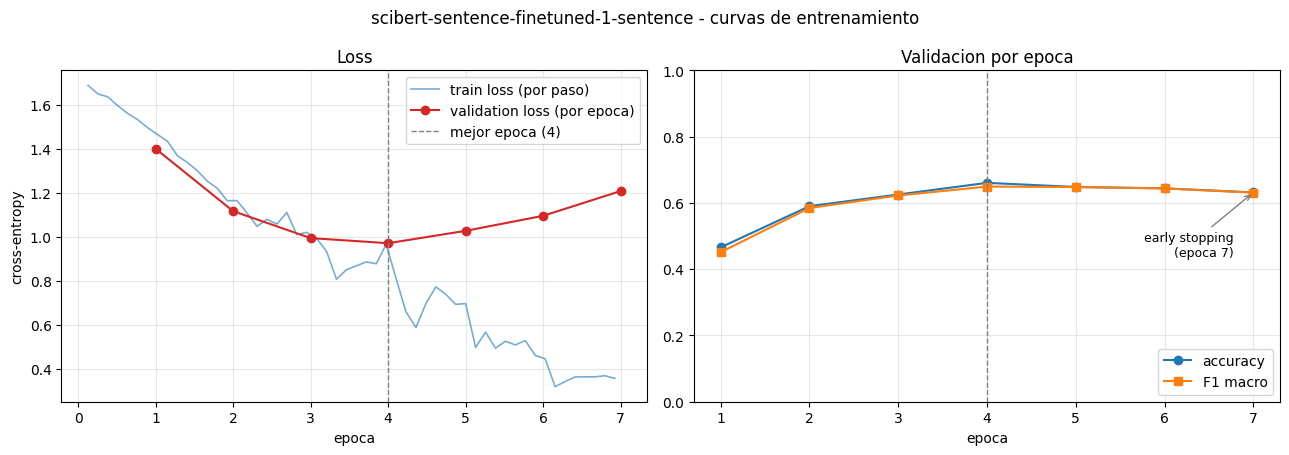

,step,epoch,eval_loss,eval_accuracy,eval_f1_macro
0,78,1.0,1.4009,0.4658,0.4514
1,156,2.0,1.1171,0.5901,0.5845
2,234,3.0,0.9945,0.6253,0.6223
3,312,4.0,0.9714,0.6605,0.6492
4,390,5.0,1.0276,0.6480,0.6478
5,468,6.0,1.0959,0.6439,0.6435
6,546,7.0,1.2086,0.6315,0.6310


In [14]:
history = pd.DataFrame(trainer.state.log_history)

if "loss" in history.columns:
    train_curve = history.dropna(subset=["loss"])[["step", "epoch", "loss"]].reset_index(drop=True)
else:
    train_curve = pd.DataFrame(columns=["step", "epoch", "loss"])

eval_cols = ["step", "epoch", "eval_loss", "eval_accuracy", f"eval_{METRIC_FOR_BEST}", "eval_f1_macro"]
eval_cols = list(dict.fromkeys(c for c in eval_cols if c in history.columns))
eval_curve = history.dropna(subset=["eval_loss"])[eval_cols].reset_index(drop=True)

best_row = eval_curve[f"eval_{METRIC_FOR_BEST}"].idxmax()
best_epoch = float(eval_curve.loc[best_row, "epoch"])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

ax = axes[0]
if len(train_curve):
    ax.plot(train_curve["epoch"], train_curve["loss"], color="tab:blue", alpha=0.6,
            lw=1.2, label="train loss (por paso)")
ax.plot(eval_curve["epoch"], eval_curve["eval_loss"], "o-", color="tab:red",
        label="validation loss (por epoca)")
ax.axvline(best_epoch, ls="--", color="gray", lw=1, label=f"mejor epoca ({best_epoch:.0f})")
ax.set_xlabel("epoca")
ax.set_ylabel("cross-entropy")
ax.set_title("Loss")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(eval_curve["epoch"], eval_curve["eval_accuracy"], "o-", label="accuracy")
ax.plot(eval_curve["epoch"], eval_curve["eval_f1_macro"], "s-", label="F1 macro")
ax.axvline(best_epoch, ls="--", color="gray", lw=1)
if early_stopped:
    last_epoch = float(eval_curve["epoch"].iloc[-1])
    last_acc = float(eval_curve["eval_accuracy"].iloc[-1])
    ax.annotate(f"early stopping\n(epoca {last_epoch:.0f})", xy=(last_epoch, last_acc),
                xytext=(-14, -46), textcoords="offset points", ha="right", fontsize=9,
                arrowprops=dict(arrowstyle="->", color="gray"))
ax.set_ylim(0, 1)
ax.set_xlabel("epoca")
ax.set_title("Validacion por epoca")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

fig.suptitle(f"{RUN_NAME} - curvas de entrenamiento", fontsize=12)
plt.tight_layout()

curves_dir = Path(tempfile.mkdtemp())
curves_path = curves_dir / "training_curves.png"
fig.savefig(curves_path, dpi=160, bbox_inches="tight")
plt.show()

mlf_log_artifact(curves_path, "training")

# Estos numeros describen el entrenamiento, no el desempeno del modelo: se registran
# como parametros para no ensuciar la lista de metricas acordada por el equipo.
if mlf_active():
    mlflow.log_params({
        "best_epoch": int(best_epoch),
        "epochs_trained": int(epochs_trained),
        "early_stopped": early_stopped,
        f"best_val_{METRIC_FOR_BEST}": round(best_metric, 4),
    })

eval_curve.round(4)

## 11. Evaluacion en validacion

Con los pesos de la mejor epoca. Las probabilidades salen del softmax sobre los logits y se conservan en `predictions_validation.csv` para analisis posteriores (calibracion, ejemplos dificiles).

In [15]:
val_output = trainer.predict(val_ds)
val_logits = val_output.predictions[0] if isinstance(val_output.predictions, tuple) else val_output.predictions
val_probs = torch.softmax(torch.tensor(val_logits, dtype=torch.float32), dim=-1).numpy()
val_pred = [id2label[int(i)] for i in val_probs.argmax(axis=-1)]
val_probs = pd.DataFrame(val_probs, columns=LABELS, index=val_df.index)

val_metrics = score(val_df[LABEL_COL].tolist(), val_pred)
val_report = classification_report(
    val_df[LABEL_COL], val_pred, labels=LABELS, output_dict=True, zero_division=0
)

print(json.dumps(val_metrics, indent=2))
print()
print(classification_report(val_df[LABEL_COL], val_pred, labels=LABELS, zero_division=0))

registradas = mlf_log_scores(val_metrics, "val")
print("\nRegistradas en MLflow:", ", ".join(sorted(registradas)))

{
  "accuracy": 0.660455486542443,
  "precision_macro": 0.6692621921890215,
  "recall_macro": 0.6552680181808382,
  "f1_macro": 0.6492152065969593,
  "f1_micro": 0.660455486542443
}

              precision    recall  f1-score   support

 Application       0.61      0.81      0.70       102
  Background       0.57      0.71      0.63        89
  Comparison       0.72      0.70      0.71       108
         Gap       0.67      0.37      0.48        91
 Improvement       0.77      0.68      0.72        93

    accuracy                           0.66       483
   macro avg       0.67      0.66      0.65       483
weighted avg       0.67      0.66      0.65       483


Registradas en MLflow: val_accuracy, val_f1_macro, val_f1_micro, val_precision_macro, val_recall_macro


## 12. Matriz de confusion de validacion

Conteos (izquierda) y normalizada por fila (derecha: la diagonal es el recall de cada clase). Debajo, los pares real -> predicha mas frecuentes, que es lo que conviene discutir en el reporte.

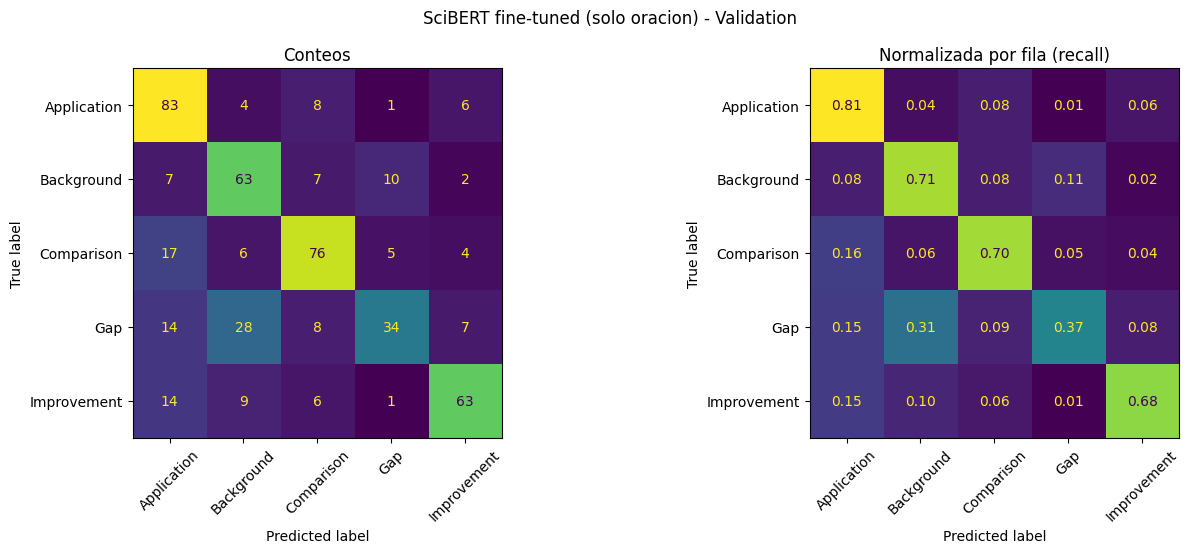

,real,predicha,n,fraccion_de_la_clase_real
0,Gap,Background,28,0.308
1,Comparison,Application,17,0.157
2,Gap,Application,14,0.154
3,Improvement,Application,14,0.151
4,Background,Gap,10,0.112
5,Improvement,Background,9,0.097


In [16]:
cm = confusion_matrix(val_df[LABEL_COL], val_pred, labels=LABELS)
row_totals = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_totals, out=np.zeros_like(cm, dtype=float), where=row_totals > 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS).plot(
    ax=axes[0], xticks_rotation=45, values_format="d", colorbar=False
)
axes[0].set_title("Conteos")
ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=LABELS).plot(
    ax=axes[1], xticks_rotation=45, values_format=".2f", colorbar=False
)
axes[1].set_title("Normalizada por fila (recall)")
fig.suptitle("SciBERT fine-tuned (solo oracion) - Validation", fontsize=12)
plt.tight_layout()

cm_path = curves_dir / "confusion_matrix_validation.png"
fig.savefig(cm_path, dpi=160, bbox_inches="tight")
plt.show()
mlf_log_artifact(cm_path, "evaluation")

confusiones = [
    (LABELS[i], LABELS[j], int(cm[i, j]), round(float(cm_norm[i, j]), 3))
    for i in range(len(LABELS)) for j in range(len(LABELS)) if i != j and cm[i, j] > 0
]
pd.DataFrame(
    sorted(confusiones, key=lambda t: -t[2])[:6],
    columns=["real", "predicha", "n", "fraccion_de_la_clase_real"],
)

## 13. Artefactos y cierre del run

Se registran etiquetas, reporte de clasificacion, historial de entrenamiento y predicciones con probabilidades: todos pesan pocos KB y suben en segundos.

El modelo de la mejor epoca se guarda de dos formas:

1. **En disco** (`SAVE_MODEL_LOCAL`): carpeta `best_model_<run_name>/` junto al notebook, en formato Hugging Face, recargable con `from_pretrained(carpeta)`. Es inmediato y sirve como respaldo si la subida falla.
2. **En MLflow** (`LOG_MODEL_TO_MLFLOW`): con `mlflow.transformers.log_model`, el equivalente para Hugging Face de `mlflow.sklearn.log_model`. Crea un **LoggedModel**, que es lo que hace aparecer el nombre del modelo en la columna *Models* de la tabla de corridas, y se recarga con `mlflow.transformers.load_model(model_uri)`.

Ese flavor construye internamente un `pipeline` de transformers, que importa `torchvision` aunque el modelo sea de texto: si falta, la celda lo dice y sube la carpeta como artefacto plano en lugar de fallar. Las dependencias se fijan explicitamente con las versiones instaladas para que MLflow no tenga que inferirlas, paso que puede tardar varios minutos.

Son ~440 MB por HTTP en cualquiera de las dos rutas; se imprime el tamano antes de empezar y el tiempo al terminar. Los demas artefactos pesan pocos KB.

In [17]:
if mlf_active():
    with tempfile.TemporaryDirectory() as tmp:
        tmp = Path(tmp)

        (tmp / "labels.json").write_text(json.dumps(LABELS), encoding="utf-8")
        (tmp / "classification_report_validation.json").write_text(
            json.dumps(val_report, indent=2), encoding="utf-8"
        )
        history.to_csv(tmp / "training_history.csv", index=False)

        keep_cols = [c for c in (ID_COL, GROUP_COL, LABEL_COL, "sentence_source", SENT_COL)
                     if c in val_df.columns]
        pred_out = val_df[keep_cols].copy()
        pred_out["prediction"] = val_pred
        pred_out["correct"] = pred_out[LABEL_COL] == pred_out["prediction"]
        pred_out = pd.concat([pred_out, val_probs.add_prefix("prob_")], axis=1)
        pred_out.to_csv(tmp / "predictions_validation.csv", index=False)

        mlflow.log_artifact(str(tmp / "labels.json"), artifact_path="evaluation")
        mlflow.log_artifact(str(tmp / "classification_report_validation.json"), artifact_path="evaluation")
        mlflow.log_artifact(str(tmp / "predictions_validation.csv"), artifact_path="evaluation")
        mlflow.log_artifact(str(tmp / "training_history.csv"), artifact_path="training")

    model_dir = WORK_DIR / MODEL_NAME
    size_mb = 0.0

    if SAVE_MODEL_LOCAL:
        trainer.save_model(str(model_dir))              # pesos + tokenizador + config
        size_mb = sum(f.stat().st_size for f in model_dir.rglob("*") if f.is_file()) / 1024 ** 2
        print(f"\nModelo guardado en {model_dir} ({size_mb:,.0f} MB)")
        mlflow.log_param("model_local_dir", MODEL_NAME)

    if LOG_MODEL_TO_MLFLOW:
        # Versiones explicitas: evita que MLflow tenga que inferir el entorno.
        requisitos = [
            f"torch=={torch.__version__.split('+')[0]}",
            f"transformers=={transformers.__version__}",
        ]
        logged_model = None

        if MODEL_FLAVOR:
            try:
                import torchvision   # noqa: F401  el pipeline de transformers lo importa

                requisitos.append(f"torchvision=={torchvision.__version__.split('+')[0]}")
            except ImportError:
                print("\nAVISO: falta torchvision, que necesita el flavor mlflow.transformers.")
                print("       Instalalo con `pip install torchvision` (debe coincidir con tu torch).")
                print("       Por ahora se sube la carpeta como artefacto plano.")
            else:
                try:
                    import mlflow.transformers

                    print(f"\nRegistrando el modelo en MLflow (~{size_mb or 440:,.0f} MB), puede tardar...")
                    inicio = time.time()
                    logged_model = mlflow.transformers.log_model(
                        transformers_model={"model": trainer.model, "tokenizer": tokenizer},
                        task="text-classification",
                        name=MODEL_NAME,
                        pip_requirements=requisitos,
                    )
                    print(f"  LoggedModel listo en {time.time() - inicio:,.0f} s: {logged_model.model_uri}")
                except Exception as exc:
                    print("AVISO: mlflow.transformers fallo, se sube la carpeta como artefacto plano.")
                    print("      ", type(exc).__name__, exc)

        if logged_model is None:
            if not model_dir.exists():                  # SAVE_MODEL_LOCAL estaba apagado
                trainer.save_model(str(model_dir))
                size_mb = sum(f.stat().st_size for f in model_dir.rglob("*") if f.is_file()) / 1024 ** 2
            print(f"Subiendo {size_mb:,.0f} MB como artefacto plano...")
            inicio = time.time()
            mlflow.log_artifacts(str(model_dir), artifact_path=MODEL_NAME)
            print(f"  subida completa en {time.time() - inicio:,.0f} s")

    mlflow.end_run()
    print("\nRun cerrado:", RUN_ID)
    print("Experimento:", MLFLOW_EXPERIMENT)
    print("Run        :", RUN_NAME)
    if MLFLOW_TRACKING_URI.startswith("http"):
        print("URL        :", f"{MLFLOW_TRACKING_URI}/#/experiments/{EXPERIMENT_ID}/runs/{RUN_ID}")
else:
    print("Sin run activo: no se registraron artefactos.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Modelo guardado en /content/best_model_scibert-sentence-finetuned-1-sentence (420 MB)

Registrando el modelo en MLflow (~420 MB), puede tardar...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  LoggedModel listo en 24 s: models:/m-87ef9da6f5f0481d81fabf49b2a3917c
🏃 View run scibert-sentence-finetuned-1-sentence at: http://98.80.92.131:8080/#/experiments/2/runs/1830ccb55b424fdc8a2a4f7ed8e633f5
🧪 View experiment at: http://98.80.92.131:8080/#/experiments/2

Run cerrado: 1830ccb55b424fdc8a2a4f7ed8e633f5
Experimento: intencite-model-comparison
Run        : scibert-sentence-finetuned-1-sentence
URL        : http://98.80.92.131:8080/#/experiments/2/runs/1830ccb55b424fdc8a2a4f7ed8e633f5


## 14. Funcion de inferencia

Recibe un parrafo con un marcador `<cite>`, extrae la oracion de la cita con la misma heuristica de la seccion 3 (en inferencia no hay `inst_id`) y devuelve la clase y las probabilidades. Es la firma que expondra la API del demostrador.

In [18]:
inference_model = trainer.model.eval()


@torch.no_grad()
def predict_citation_function(text: str) -> dict:
    sentence, source = extract_cite_sentence(text)
    enc = tokenizer(sentence, truncation=True, max_length=MAX_LEN, return_tensors="pt")
    enc = {k: v.to(inference_model.device) for k, v in enc.items()}
    probs = torch.softmax(inference_model(**enc).logits[0].float(), dim=-1).cpu().numpy()
    return {
        "prediction": id2label[int(probs.argmax())],
        "probabilities": {label: float(p) for label, p in zip(LABELS, probs)},
        "sentence": sentence,
        "sentence_source": source,
    }


example_text = (
    "Citation intent classification has been studied with feature-based models. "
    "Previous work <cite>Smith et al. (2020)</cite> introduced a similar method for citation "
    "intent classification, which we use as the basis of our experimental setup. "
    "We report results on two benchmarks."
)
predict_citation_function(example_text)

{'prediction': 'Application',
 'probabilities': {'Application': 0.5834563970565796,
  'Background': 0.009486113674938679,
  'Comparison': 0.07360314577817917,
  'Gap': 0.026294514536857605,
  'Improvement': 0.30715981125831604},
 'sentence': 'Previous work <cite>Smith et al. (2020)</cite> introduced a similar method for citation intent classification, which we use as the basis of our experimental setup.',
 'sentence_source': 'heuristic'}

## 15. Test final

`RUN_FINAL_TEST=True` solo para la evaluacion final. Las metricas de test se agregan al mismo run de MLflow (se reabre por `RUN_ID`).

In [19]:
RUN_FINAL_TEST = False

if RUN_FINAL_TEST:
    test_ds = build_dataset(test_df)
    test_output = trainer.predict(test_ds)
    test_logits = test_output.predictions[0] if isinstance(test_output.predictions, tuple) else test_output.predictions
    test_pred = [id2label[int(i)] for i in test_logits.argmax(axis=-1)]
    test_metrics = score(test_df[LABEL_COL].tolist(), test_pred)

    print(json.dumps(test_metrics, indent=2))
    print()
    print(classification_report(test_df[LABEL_COL], test_pred, labels=LABELS, zero_division=0))

    if USE_MLFLOW and RUN_ID is not None:
        mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
        with mlflow.start_run(run_id=RUN_ID):
            registradas = mlf_log_scores(test_metrics, "test")
        print("Registradas en MLflow:", ", ".join(sorted(registradas)))
else:
    print("Test reservado. Cambia RUN_FINAL_TEST=True unicamente para la evaluacion final.")

Test reservado. Cambia RUN_FINAL_TEST=True unicamente para la evaluacion final.
